In [2]:
import pandas as pd

load the dataset

In [3]:
df = pd.read_csv(
    '../data/raw/household_power_consumption.txt',
    sep=';',
    na_values='?'
    )

Create a Datetime column

In [4]:
df['Datetime'] = pd.to_datetime(
    df['Date'] + ' ' + df['Time'],
    dayfirst=True
)

In [5]:
full_range = pd.date_range(
    start=df["Datetime"].min(),
    end=df["Datetime"].max(),
    freq="min"
)

print(len(full_range))
print(len(df))

2075259
2075259


In [6]:
missing = full_range.difference(df["Datetime"])

print(len(missing))

0


In [7]:
start=df["Datetime"].min()
start

Timestamp('2006-12-16 17:24:00')

In [8]:
end=df["Datetime"].max()
end

Timestamp('2010-11-26 21:02:00')

In [9]:
df.shape

(2075259, 10)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2075259 entries, 0 to 2075258
Data columns (total 10 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   Date                   object        
 1   Time                   object        
 2   Global_active_power    float64       
 3   Global_reactive_power  float64       
 4   Voltage                float64       
 5   Global_intensity       float64       
 6   Sub_metering_1         float64       
 7   Sub_metering_2         float64       
 8   Sub_metering_3         float64       
 9   Datetime               datetime64[ns]
dtypes: datetime64[ns](1), float64(7), object(2)
memory usage: 158.3+ MB


In [11]:
df.isna().sum()

Date                         0
Time                         0
Global_active_power      25979
Global_reactive_power    25979
Voltage                  25979
Global_intensity         25979
Sub_metering_1           25979
Sub_metering_2           25979
Sub_metering_3           25979
Datetime                     0
dtype: int64

In [12]:
(df.isnull().sum() / len(df)) * 100

Date                     0.000000
Time                     0.000000
Global_active_power      1.251844
Global_reactive_power    1.251844
Voltage                  1.251844
Global_intensity         1.251844
Sub_metering_1           1.251844
Sub_metering_2           1.251844
Sub_metering_3           1.251844
Datetime                 0.000000
dtype: float64

In [13]:
df.duplicated().sum()

0

In [14]:
df = (
    df
    .set_index('Datetime')
    .drop(columns=['Date', 'Time'])
)

In [15]:
df = df.interpolate(method='time')

In [16]:
df.isna().sum()

Global_active_power      0
Global_reactive_power    0
Voltage                  0
Global_intensity         0
Sub_metering_1           0
Sub_metering_2           0
Sub_metering_3           0
dtype: int64

In [17]:
df.describe()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
count,2.075259e+06,2.075259e+06,2.075259e+06,2.075259e+06,2.075259e+06,2.075259e+06,2.075259e+06
mean,1.090280e+00,1.236492e-01,2.408328e+02,4.621481e+00,1.109485e+00,1.289229e+00,6.442386e+00
std,1.052628e+00,1.124194e-01,3.237763e+00,4.424361e+00,6.115843e+00,5.786613e+00,8.415860e+00
min,7.600000e-02,0.000000e+00,2.232000e+02,2.000000e-01,0.000000e+00,0.000000e+00,0.000000e+00
25%,3.100000e-01,4.800000e-02,2.389900e+02,1.400000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,6.140000e-01,1.000000e-01,2.410000e+02,2.751585e+00,0.000000e+00,0.000000e+00,1.000000e+00
75%,1.528000e+00,1.940000e-01,2.428700e+02,6.400000e+00,0.000000e+00,1.000000e+00,1.700000e+01
max,1.112200e+01,1.390000e+00,2.541500e+02,4.840000e+01,8.800000e+01,8.000000e+01,3.100000e+01


In [18]:
import matplotlib.pyplot as plt

In [19]:
numerical_cols = [
    "Global_active_power",
    "Global_reactive_power",
    "Voltage",
    "Global_intensity",
    "Sub_metering_1",
    "Sub_metering_2",
    "Sub_metering_3"
]


In [20]:

outliers_summary = {}

for col in numerical_cols:
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    ]

    outliers_summary[col] = {
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Number of Outliers": len(outliers),
        "Percentage": round((len(outliers)/len(df))*100,2)
    }


iqr_results = pd.DataFrame(outliers_summary).T

iqr_results

,Q1,Q3,IQR,Lower Bound,Upper Bound,Number of Outliers,Percentage
Global_active_power,0.310,1.528,1.218,-1.517,3.355,95238.0,4.59
Global_reactive_power,0.048,0.194,0.146,-0.171,0.413,40478.0,1.95
Voltage,238.990,242.870,3.880,233.170,248.690,52195.0,2.52
Global_intensity,1.400,6.400,5.000,-6.100,13.900,100979.0,4.87
Sub_metering_1,0.000,0.000,0.000,0.000,0.000,172247.0,8.30
Sub_metering_2,0.000,1.000,1.000,-1.500,2.500,77166.0,3.72
Sub_metering_3,0.000,17.000,17.000,-25.500,42.500,0.0,0.00


In [21]:
df['Hour'] = df.index.hour

In [22]:
df['Day'] = df.index.day

In [23]:
df['Month'] = df.index.month

In [24]:
df['DayOfWeek'] = df.index.dayofweek

In [25]:
df['Year'] = df.index.year

In [26]:

df[['Hour', 'Day', 'Month', 'DayOfWeek', 'Year']].head()

,Hour,Day,Month,DayOfWeek,Year
Datetime,,,,,
2006-12-16 17:24:00,17,16,12,5,2006
2006-12-16 17:25:00,17,16,12,5,2006
2006-12-16 17:26:00,17,16,12,5,2006
2006-12-16 17:27:00,17,16,12,5,2006
2006-12-16 17:28:00,17,16,12,5,2006


In [27]:
df["IsWeekend"] = df["DayOfWeek"].isin([5, 6]).astype(int)

In [28]:
df[["DayOfWeek", "IsWeekend"]].head()

,DayOfWeek,IsWeekend
Datetime,,
2006-12-16 17:24:00,5,1
2006-12-16 17:25:00,5,1
2006-12-16 17:26:00,5,1
2006-12-16 17:27:00,5,1
2006-12-16 17:28:00,5,1


array([[<Axes: title={'center': 'Global_active_power'}>,
        <Axes: title={'center': 'Global_reactive_power'}>,
        <Axes: title={'center': 'Voltage'}>,
        <Axes: title={'center': 'Global_intensity'}>],
       [<Axes: title={'center': 'Sub_metering_1'}>,
        <Axes: title={'center': 'Sub_metering_2'}>,
        <Axes: title={'center': 'Sub_metering_3'}>,
        <Axes: title={'center': 'Hour'}>],
       [<Axes: title={'center': 'Day'}>,
        <Axes: title={'center': 'Month'}>,
        <Axes: title={'center': 'DayOfWeek'}>,
        <Axes: title={'center': 'Year'}>],
       [<Axes: title={'center': 'IsWeekend'}>, <Axes: >, <Axes: >,
        <Axes: >]], dtype=object)

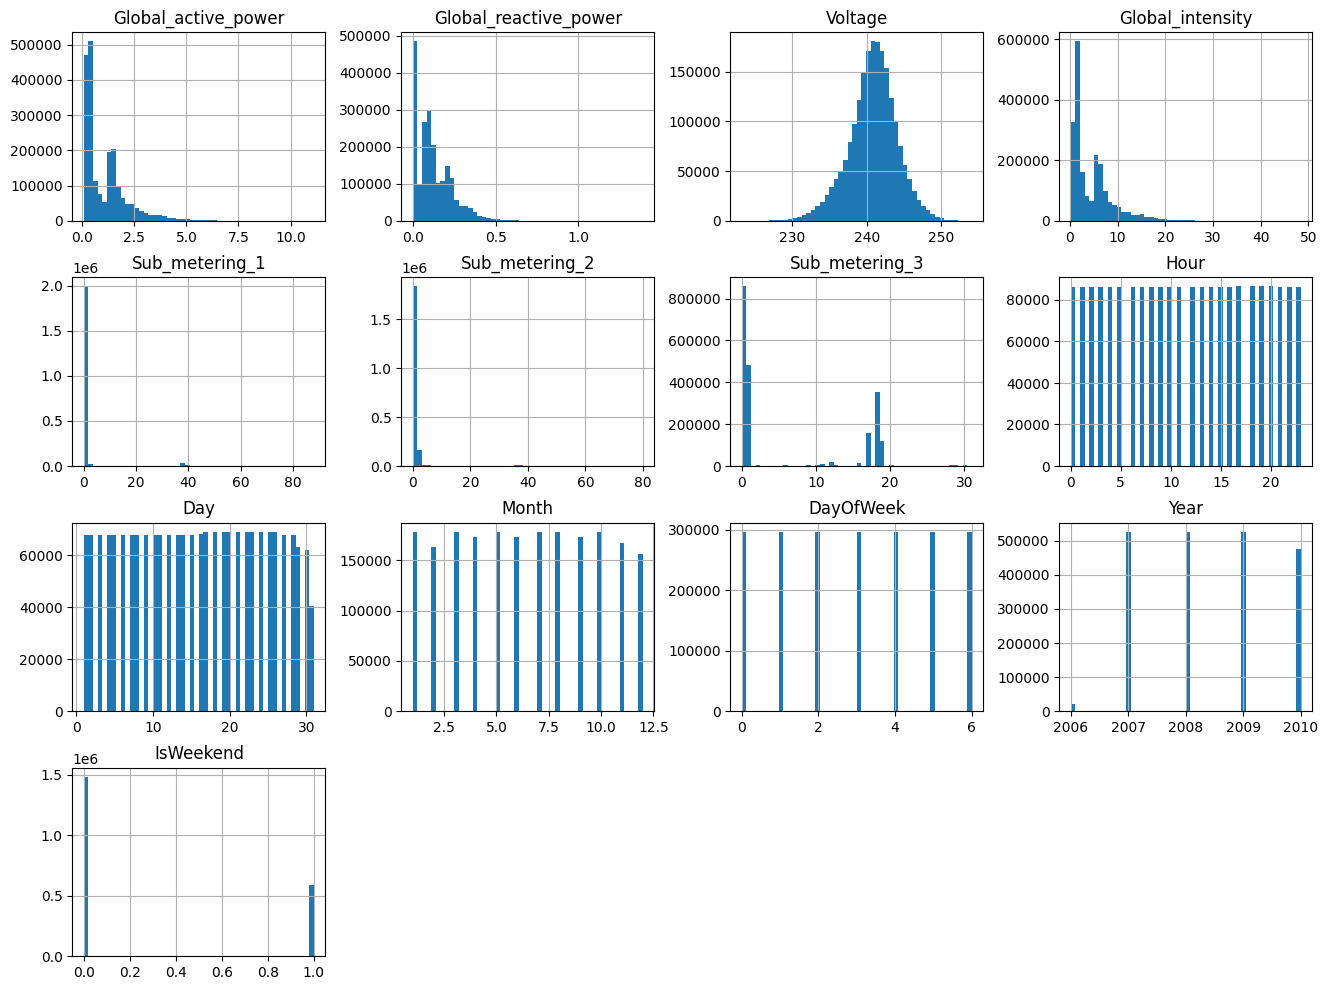

In [29]:
df.hist(figsize=(16, 12), bins=50)

In [30]:
df.corr()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Hour,Day,Month,DayOfWeek,Year,IsWeekend
Global_active_power,1.000000,0.245047,-0.395522,0.998887,0.483816,0.433892,0.639272,0.279776,-0.000023,-0.033133,0.061637,-0.032399,0.079886
Global_reactive_power,0.245047,1.000000,-0.109030,0.264162,0.122743,0.139204,0.087743,0.126564,-0.000854,0.023382,0.073064,0.043915,0.092437
Voltage,-0.395522,-0.109030,1.000000,-0.407198,-0.194100,-0.165348,-0.265510,-0.173498,0.016549,-0.017579,-0.020578,0.256018,-0.023377
Global_intensity,0.998887,0.264162,-0.407198,1.000000,0.488756,0.439713,0.627264,0.280167,-0.000598,-0.031788,0.063099,-0.036879,0.081862
Sub_metering_1,0.483816,0.122743,-0.194100,0.488756,1.000000,0.055011,0.102704,0.107943,-0.006632,-0.007655,0.051548,-0.013993,0.063244
Sub_metering_2,0.433892,0.139204,-0.165348,0.439713,0.055011,1.000000,0.080710,0.086807,0.002417,-0.009770,0.031258,-0.036428,0.041598
Sub_metering_3,0.639272,0.087743,-0.265510,0.627264,0.102704,0.080710,1.000000,0.113130,-0.003295,-0.030246,0.009178,0.061693,0.014625
Hour,0.279776,0.126564,-0.173498,0.280167,0.107943,0.086807,0.113130,1.000000,-0.000145,0.000216,0.000175,-0.000696,0.000461
Day,-0.000023,-0.000854,0.016549,-0.000598,-0.006632,0.002417,-0.003295,-0.000145,1.000000,0.020129,0.007873,-0.028265,0.006312
Month,-0.033133,0.023382,-0.017579,-0.031788,-0.007655,-0.009770,-0.030246,0.000216,0.020129,1.000000,-0.000265,-0.089253,0.001542


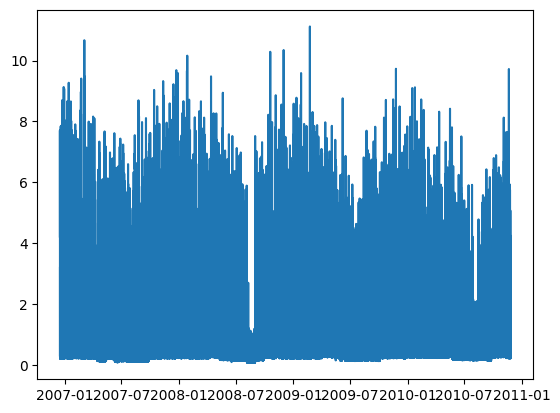

In [31]:
plt.plot(df.index, df["Global_active_power"])

In [32]:
df_daily = pd.DataFrame()

df_daily["Daily_Energy_kWh"] = (
    df["Global_active_power"] / 60
).resample("D").sum()

In [33]:
df_daily.head()

,Daily_Energy_kWh
Datetime,
2006-12-16,20.152933
2006-12-17,56.507667
2006-12-18,36.730433
2006-12-19,27.769900
2006-12-20,37.095800


In [34]:
df_daily.shape

(1442, 1)

In [35]:
df_daily.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1442 entries, 2006-12-16 to 2010-11-26
Freq: D
Data columns (total 1 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Daily_Energy_kWh  1442 non-null   float64
dtypes: float64(1)
memory usage: 22.5 KB


In [36]:
df_daily["Avg_Voltage"] = (
    df["Voltage"]
    .resample("D")
    .mean()
)

In [37]:
df_daily["Avg_Global_Intensity"] = (
    df["Global_intensity"]
    .resample("D")
    .mean()
)

In [38]:
df_daily["Avg_Global_Reactive_Power"] = (
    df["Global_reactive_power"]
    .resample("D")
    .mean()
)

In [39]:
df_daily['Month'] = df_daily.index.month

In [40]:
df_daily['DayOfWeek'] = df_daily.index.dayofweek

In [41]:
df_daily["IsWeekend"] = df_daily["DayOfWeek"].isin([5, 6]).astype(int)

In [42]:
df_daily['Year'] = df_daily.index.year

In [43]:
df_daily.head()

,Daily_Energy_kWh,Avg_Voltage,Avg_Global_Intensity,Avg_Global_Reactive_Power,Month,DayOfWeek,IsWeekend,Year
Datetime,,,,,,,,
2006-12-16,20.152933,236.243763,13.082828,0.088187,12,5,1,2006
2006-12-17,56.507667,240.087028,9.999028,0.156949,12,6,1,2006
2006-12-18,36.730433,241.231694,6.421667,0.112356,12,0,0,2006
2006-12-19,27.769900,241.999313,4.926389,0.104821,12,1,0,2006
2006-12-20,37.095800,242.308062,6.467361,0.111804,12,2,0,2006


In [44]:
df_daily.describe()

,Daily_Energy_kWh,Avg_Voltage,Avg_Global_Intensity,Avg_Global_Reactive_Power,Month,DayOfWeek,IsWeekend,Year
count,1442.000000,1442.000000,1442.000000,1442.000000,1442.000000,1442.000000,1442.000000,1442.000000
mean,26.151322,240.830431,4.625764,0.123629,6.453537,3.000000,0.285714,2008.435506
std,10.031326,2.050027,1.743678,0.034784,3.418465,2.000694,0.451911,1.130150
min,4.171633,231.088229,0.808333,0.017168,1.000000,0.000000,0.000000,2006.000000
25%,19.468350,240.068363,3.500799,0.098969,3.250000,1.000000,0.000000,2007.000000
50%,25.822400,240.962701,4.549375,0.118961,6.000000,3.000000,0.000000,2008.000000
75%,31.668950,241.869840,5.539236,0.141544,9.000000,5.000000,1.000000,2009.000000
max,79.556433,247.435007,14.028056,0.290162,12.000000,6.000000,1.000000,2010.000000


In [45]:
df_daily.isna().sum()

Daily_Energy_kWh             0
Avg_Voltage                  0
Avg_Global_Intensity         0
Avg_Global_Reactive_Power    0
Month                        0
DayOfWeek                    0
IsWeekend                    0
Year                         0
dtype: int64

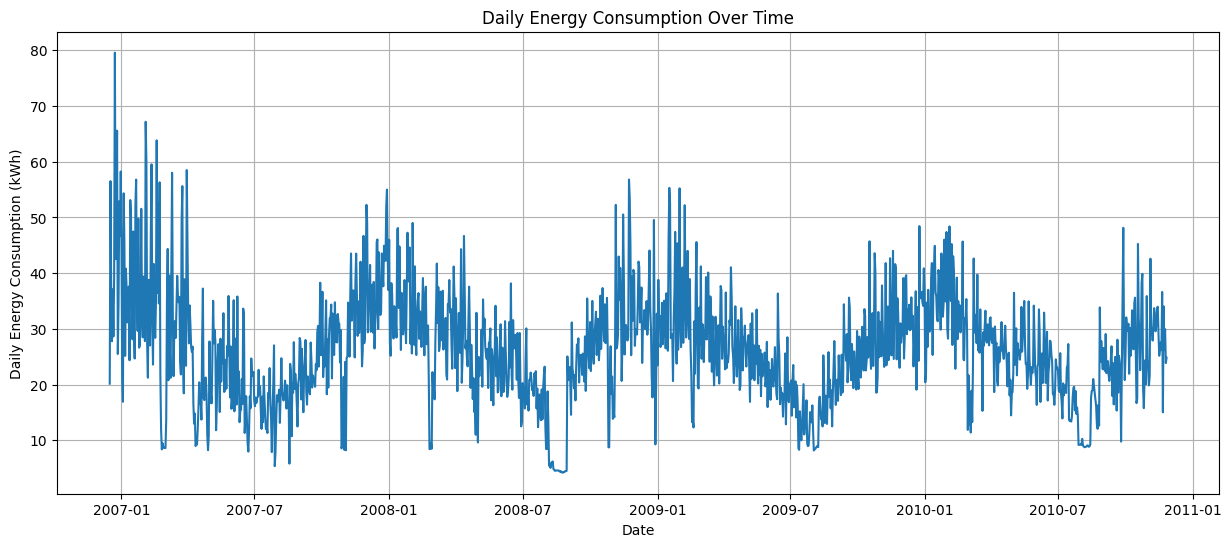

In [46]:
plt.figure(figsize=(15, 6))
plt.plot(df_daily.index, df_daily["Daily_Energy_kWh"])
plt.title('Daily Energy Consumption Over Time')
plt.xlabel('Date')
plt.ylabel('Daily Energy Consumption (kWh)')
plt.grid(True)

Text(0, 0.5, 'Frequency')

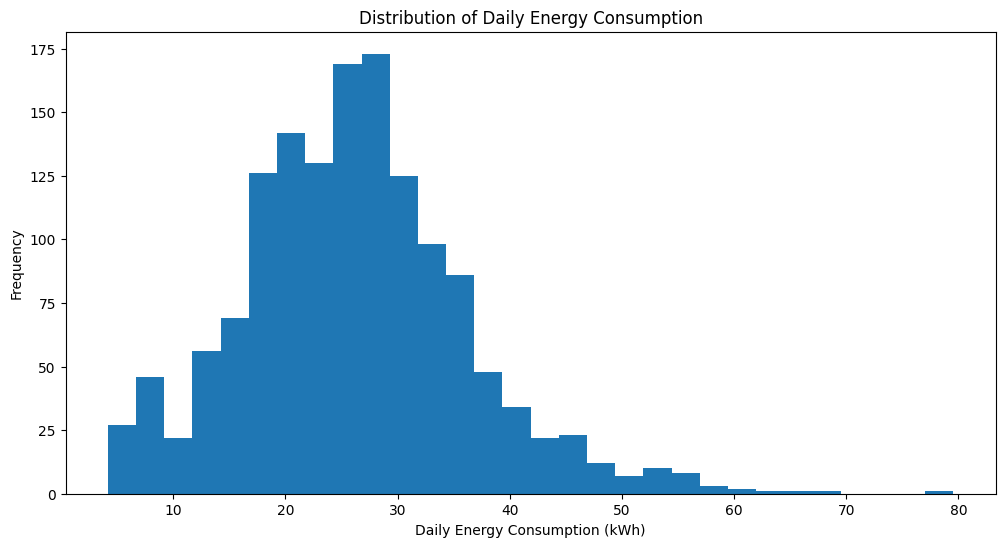

In [47]:
plt.figure(figsize=(12, 6))
plt.hist(df_daily["Daily_Energy_kWh"], bins=30)
plt.title('Distribution of Daily Energy Consumption')
plt.xlabel('Daily Energy Consumption (kWh)')
plt.ylabel('Frequency')

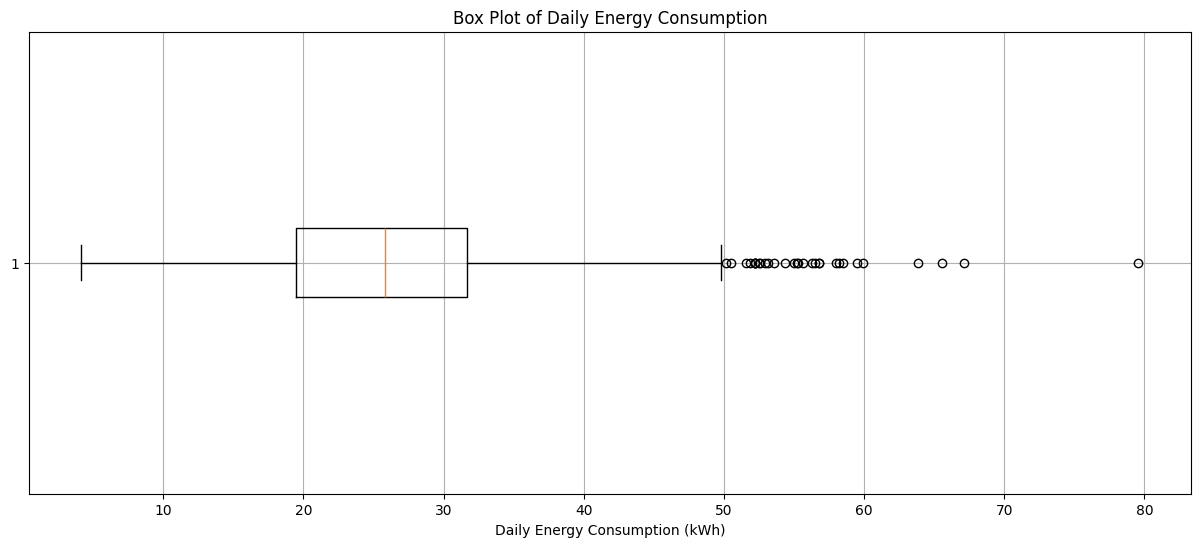

In [48]:
plt.figure(figsize=(15, 6))
plt.boxplot(df_daily["Daily_Energy_kWh"], vert=False)
plt.title('Box Plot of Daily Energy Consumption')
plt.xlabel('Daily Energy Consumption (kWh)')
plt.grid(True)

In [49]:
import seaborn as sns

Text(0.5, 1.0, 'Correlation Matrix')

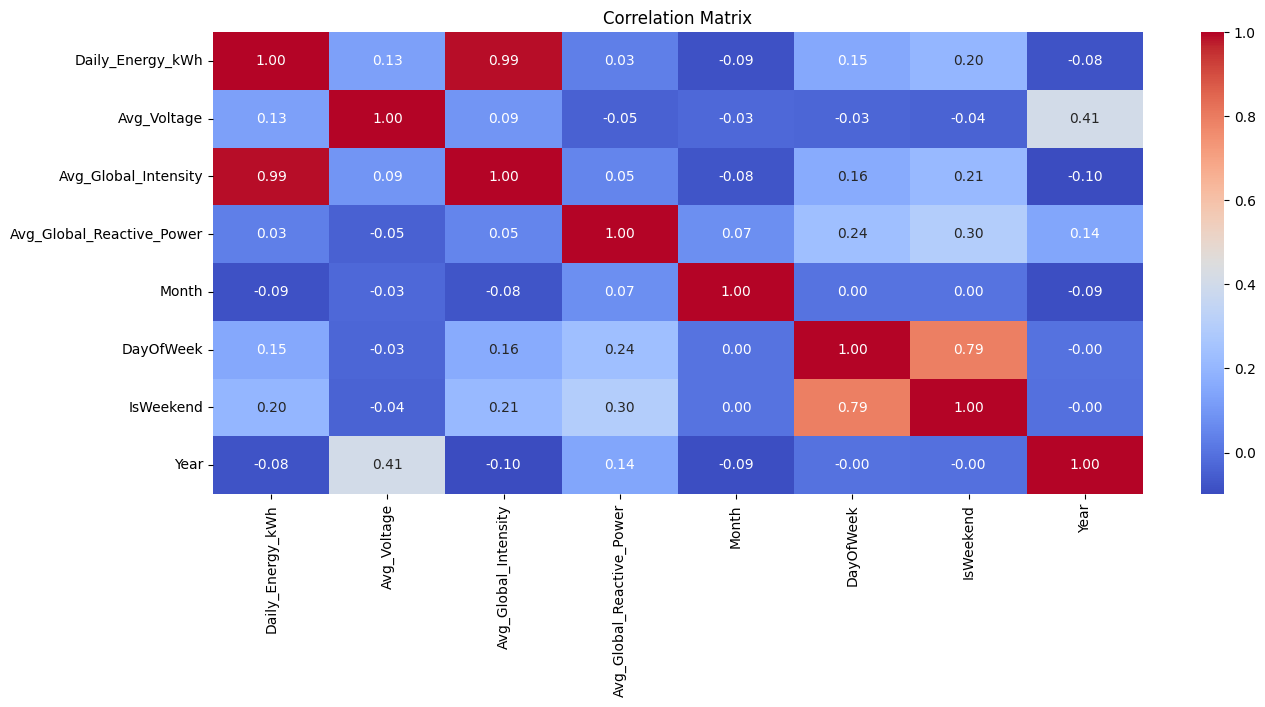

In [50]:
plt.figure(figsize=(15, 6))
sns.heatmap(df_daily.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')

Text(0, 0.5, 'Average Energy (kWh)')

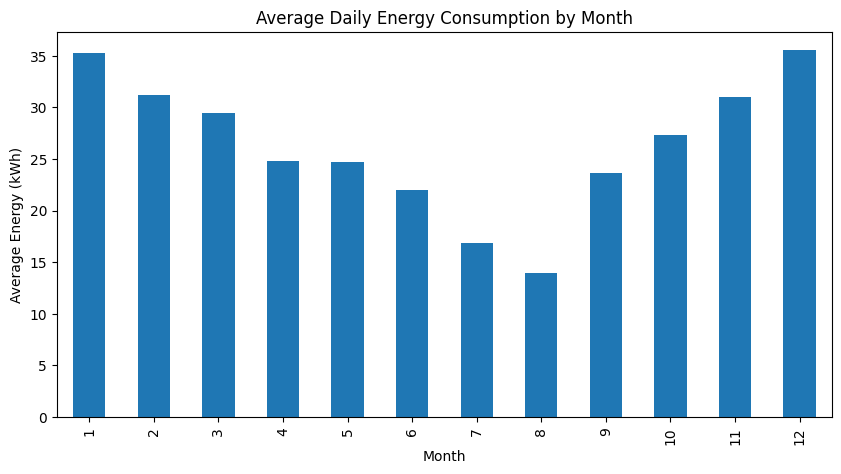

In [51]:
monthly = df_daily.groupby("Month")["Daily_Energy_kWh"].mean()

monthly.plot(kind="bar", figsize=(10,5))

plt.title("Average Daily Energy Consumption by Month")
plt.xlabel("Month")
plt.ylabel("Average Energy (kWh)")

Text(0, 0.5, 'Average Energy (kWh)')

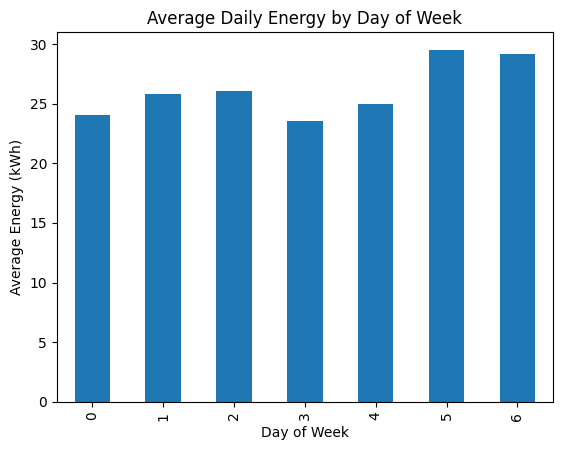

In [52]:
weekday = df_daily.groupby("DayOfWeek")["Daily_Energy_kWh"].mean()

weekday.plot(kind="bar")

plt.title("Average Daily Energy by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Energy (kWh)")

In [53]:
start_date = df_daily.index.min()
start_date

Timestamp('2006-12-16 00:00:00')

In [54]:
end_date = df_daily.index.max()
end_date

Timestamp('2010-11-26 00:00:00')